In [1]:
import os
import h5py
from H2Crop.H2Crop import H2Crop
import sys
import matplotlib.pyplot as plt
import numpy as np
from utils import visualize_sample, plot_spectral_signatures_H2Crop

In [4]:
H2Crop_dataset = H2Crop()

In [5]:
data = H2Crop_dataset.get_random_h5_sample()

if data:
    print(f"\nExtracted Array Shapes:")
    print(f" - Hyperspectral: {data['hyperspectral'].shape}")
    print(f" - Multispectral: {data['multispectral'].shape}")
    print(f" - Labels:        {data['labels'].shape}")
    print(f" - Priors:        {data['prior'].shape}")


Extracted Array Shapes:
 - Hyperspectral: (218, 64, 64)
 - Multispectral: (12, 10, 192, 192)
 - Labels:        (4, 192, 192)
 - Priors:        (4, 192, 192)


In [ ]:
list_files = H2Crop_dataset.get_file_list(from_train=False, limit=1600)
data = H2Crop_dataset.load_h5_data(file_list=list_files, keep_prior=False, data_type="multispectral", detail_layer=0, static=True)

# for sample in data:
#     print(f"\nExtracted Array Shapes:")
#     print(f" - Hyperspectral: {sample['hyperspectral'].shape}")
#     print(f" - Labels:        {sample['labels'].shape}")
#     print('\n')

Successfully sampled 1600 file IDs.


In [ ]:
def check_ram_usage(data, RAM=1):
    tot_bytes = 0

    for sample in data:
        for key,value in sample.items():
            if hasattr(value, 'nbytes'):
                tot_bytes += value.nbytes
    
    RAM_bytes = RAM * 1024 * 1024 * 1024

    print(f'RAM usage (bytes): {tot_bytes} | {RAM_bytes}')
    print(f'RAM usage (%): {round((tot_bytes * 100) / (RAM_bytes), 2)}%')

In [ ]:
check_ram_usage(data=data, RAM=16)

RAM usage (bytes): 2916352000 | 17179869184
RAM usage (%): 16.98%


# PLOT IMAGES

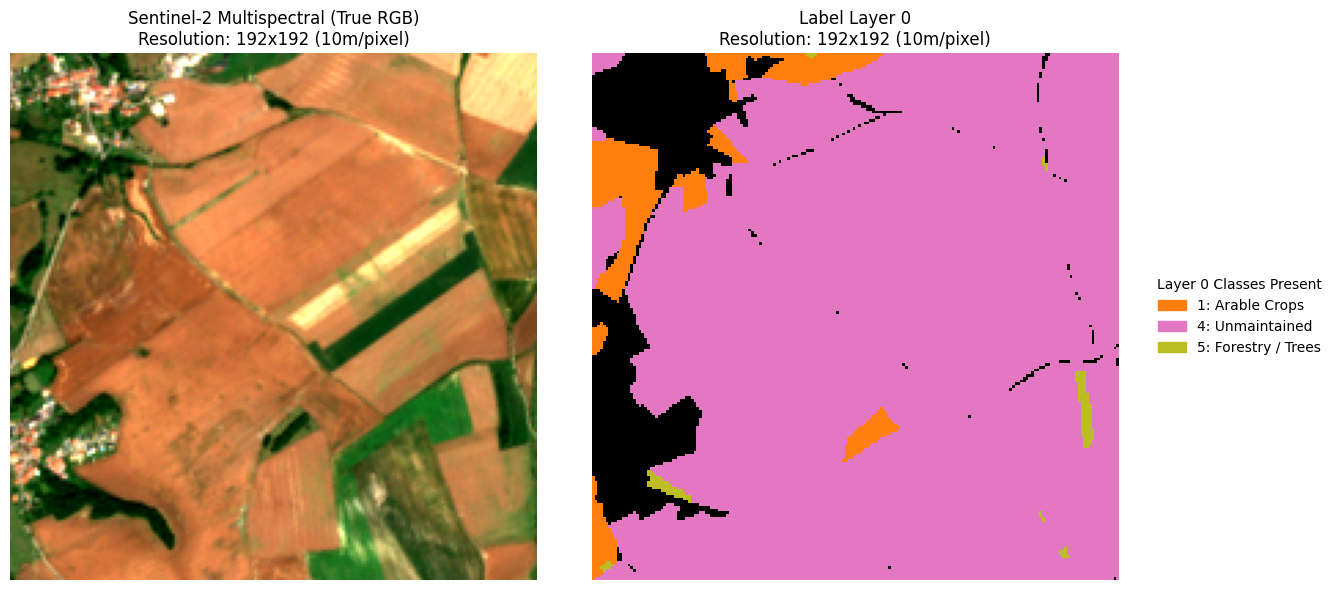

In [7]:
# Assuming you already instantiated your H2Crop class and loaded a sample:
loader = H2Crop()
my_sample = loader.get_random_h5_sample(static=True)
visualize_sample(my_sample, detail_layer=0, classes_to_drop=[0])

# ANALYSIS SPECTRAL SIGNATURES

In [2]:
file_list_path = 'results_2_H2Crop/baseline_layer_0_drop_0_3/file_sample_list.txt'

# Read File
def read_file():
    
    with open(file_list_path, "r") as f:
        file_list = f.read().splitlines()
        return file_list

file_list = read_file()

for i in range(0,5):
    print(file_list[i])

# Loader
loader = H2Crop()

20220613T112345Z_022_x320_y128_T31TFJ
20220613T112336Z_020_x512_y128_T31TFK
20220616T110219Z_032_x768_y128_T31TFJ
20220616T110126Z_020_x960_y704_T31TGM
20220613T112225Z_004_x1024_y320_T32ULV



Extracting Spectral Signatures for HYPERSPECTRAL...
Successfully loaded 300 files into memory.
-> Modality kept: 'hyperspectral'. Priors kept: False.


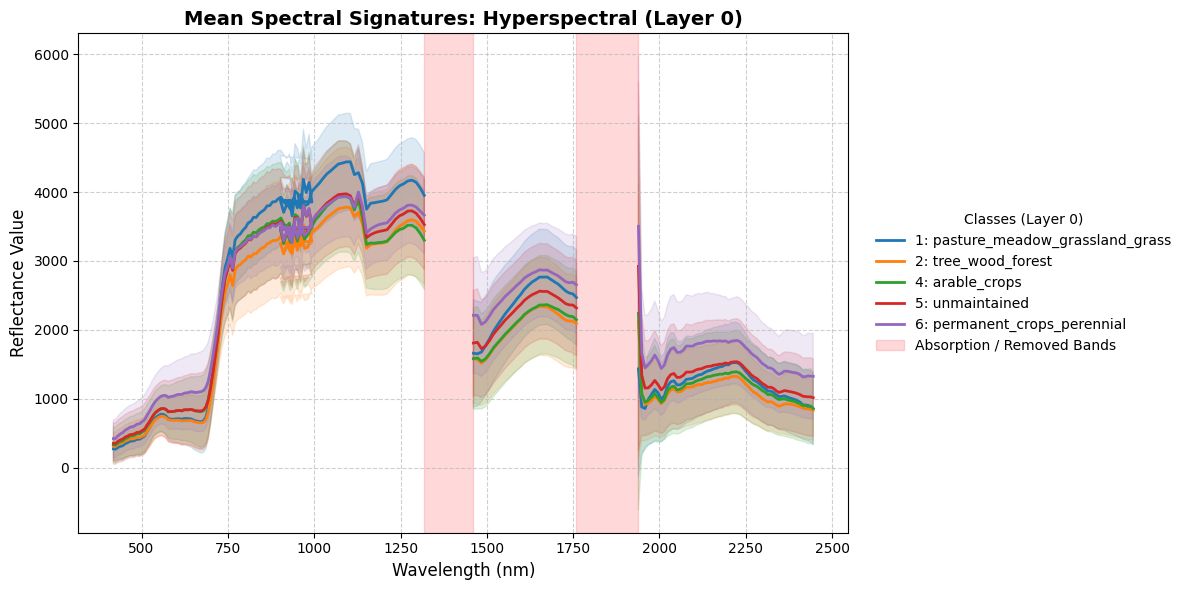


Extracting Spectral Signatures for MULTISPECTRAL...
Successfully loaded 300 files into memory.
-> Modality kept: 'multispectral'. Priors kept: False.


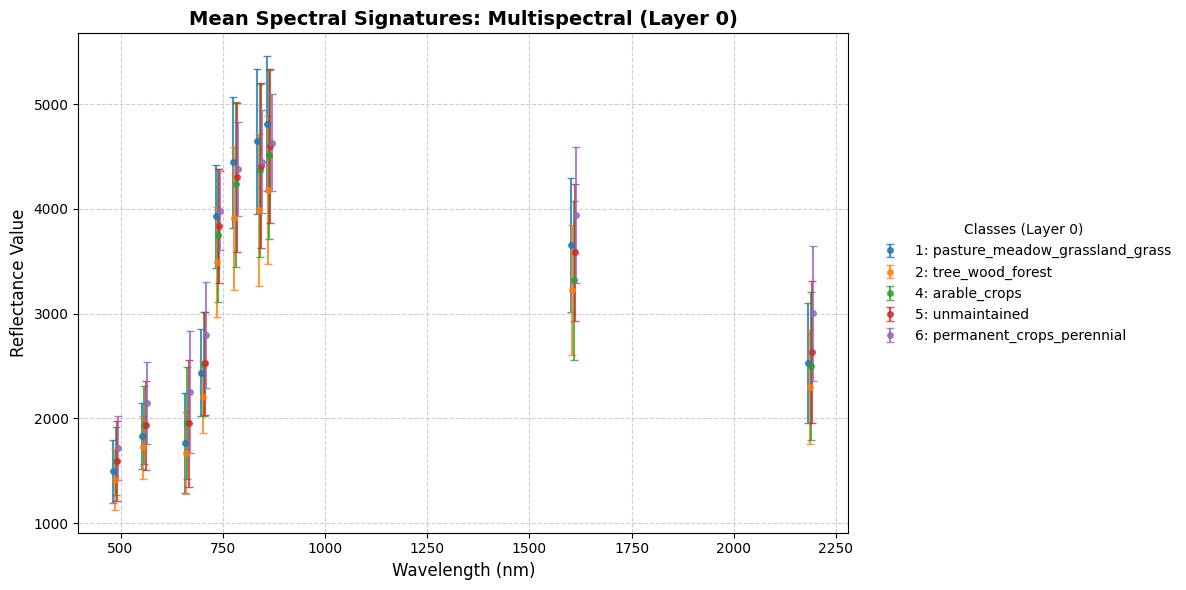

In [3]:
plot_spectral_signatures_H2Crop(
    loader=loader,
    file_list=file_list,
    modality="hyperspectral",
    detail_layer=0,
    classes_to_show=[1,2,4,5,6]
)

plot_spectral_signatures_H2Crop(
    loader=loader,
    file_list=file_list,
    modality="multispectral",
    detail_layer=0,
    classes_to_show=[1,2,4,5,6]
)